In [2]:
!pip install pytrends

c:\Users\Lucy\anaconda3\envs\py39\lib\site-packages\pytrends\request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


,inflation,recession,interest rate,unemployment
date,,,,
2025-02-23,33,7,42,41
2025-03-02,32,11,43,40
2025-03-09,36,30,44,39
2025-03-16,31,11,43,38
2025-03-23,32,9,40,35


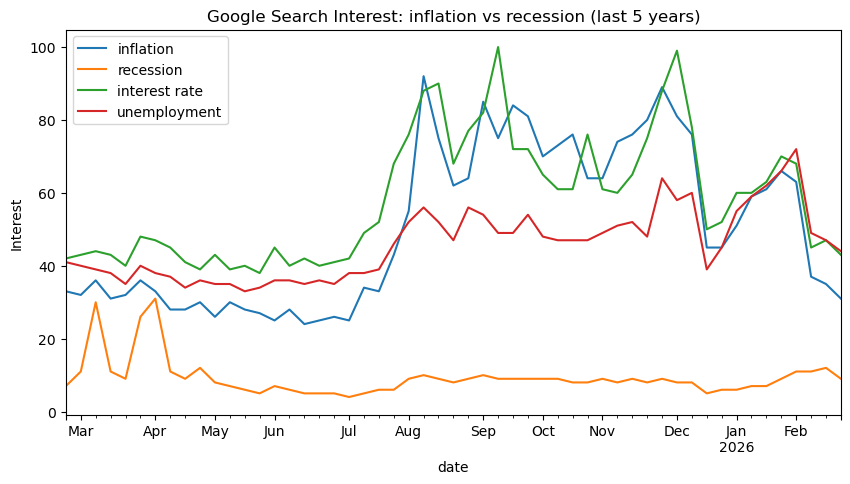

In [4]:
from pytrends.request import TrendReq

import matplotlib.pyplot as plt

pytrends = TrendReq(hl='en-US', tz=360)
keywords = ['inflation', 'recession', 'interest rate', 'unemployment']

# timeframe examples: 'today 5-y', 'today 12-m', '2020-01-01 2024-12-31'
pytrends.build_payload(kw_list=keywords, timeframe='today 12-m', geo='')  # geo='' for worldwide
df = pytrends.interest_over_time()

if df.empty:
    print("No data returned for the chosen timeframe/keywords.")
else:
    df = df.drop(columns=['isPartial'], errors='ignore')
    display(df.head())
    ax = df.plot(figsize=(10, 5))
    ax.set_title("Google Search Interest: inflation vs recession (last 5 years)")
    ax.set_ylabel("Interest")
    plt.show()

In [5]:
df.tail()

,inflation,recession,interest rate,unemployment
date,,,,
2026-01-25,66,9,70,66
2026-02-01,63,11,68,72
2026-02-08,37,11,45,49
2026-02-15,35,12,47,47
2026-02-22,31,9,43,44


In [12]:
import yfinance as yf
import pandas as pd

import matplotlib.pyplot as plt

# download S&P 500 for the df date range (include last day)
start = df.index.min()
end = df.index.max() + pd.Timedelta(days=1)
sp = yf.download("^GSPC", start=start, end=end, progress=False)[["Close"]]
sp.index = sp.index.tz_localize(None)
sp['Close'].ffill().tail()

Ticker,^GSPC
Date,
2026-02-13,6836.169922
2026-02-17,6843.220215
2026-02-18,6881.310059
2026-02-19,6861.890137
2026-02-20,6909.509766


In [ ]:

if sp.empty:
    print("No S&P 500 data returned for the requested range.")
else:
    # align S&P 500 close to df dates, forward-fill to cover non-trading days
    df["SP500_close"] = sp["Close"].reindex(df.index, method="ffill")

    # quick display and overlay on existing axes
    display(df[["SP500_close"]].head())
    ax2 = ax.twinx()
    df["SP500_close"].plot(ax=ax2, color="black", linestyle="--", label="S&P 500 Close")
    ax2.set_ylabel("S&P 500 Close")
    ax2.legend(loc="upper left")
    plt.show()

In [7]:
df.tail()

,inflation,recession,interest rate,unemployment,SP500_close
date,,,,,
2026-01-25,66,9,70,66,6915.609863
2026-02-01,63,11,68,72,6939.029785
2026-02-08,37,11,45,49,6932.299805
2026-02-15,35,12,47,47,6836.169922
2026-02-22,31,9,43,44,6909.509766


In [14]:

# compute next-day S&P 500 return (aligned with current date) using pct_change + shift
df['SP500_return_next'] = df['SP500_close'].pct_change().shift(-1)

# quick check
display(df[['SP500_close', 'SP500_return_next']].tail(10))

,SP500_close,SP500_return_next
date,,
2025-12-21,6834.500000,0.013964
2025-12-28,6929.939941,-0.010313
2026-01-04,6858.470215,0.015719
2026-01-11,6966.279785,-0.003771
2026-01-18,6940.009766,-0.003516
2026-01-25,6915.609863,0.003387
2026-02-01,6939.029785,-0.000970
2026-02-08,6932.299805,-0.013867
2026-02-15,6836.169922,0.010728


,inflation,recession,interest rate,unemployment,SP500_close,SP500_return_next
inflation,1.000000,-0.049422,0.894349,0.789599,0.645438,0.000353
recession,-0.049422,1.000000,-0.065421,-0.041448,-0.384430,-0.188321
interest rate,0.894349,-0.065421,1.000000,0.762512,0.570559,0.004953
unemployment,0.789599,-0.041448,0.762512,1.000000,0.751680,-0.080199
SP500_close,0.645438,-0.384430,0.570559,0.751680,1.000000,-0.126475
SP500_return_next,0.000353,-0.188321,0.004953,-0.080199,-0.126475,1.000000


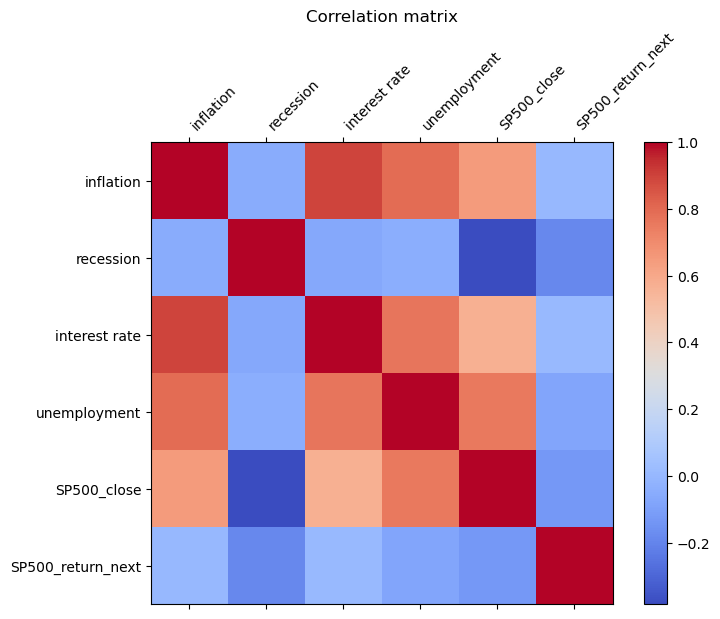

In [15]:
# compute and display correlations
corr = df.corr()
display(corr)

# simple heatmap
fig, axh = plt.subplots(figsize=(8, 6))
cax = axh.matshow(corr, cmap="coolwarm")
fig.colorbar(cax)
axh.set_xticks(range(len(corr.columns)))
axh.set_yticks(range(len(corr.columns)))
axh.set_xticklabels(corr.columns, rotation=45, ha="left")
axh.set_yticklabels(corr.columns)
axh.set_title("Correlation matrix")
plt.show()

In [ ]:
df.rolling(window=30, min_periods=15)

inflation            0.337535
recession            0.221267
interest rate        0.384788
unemployment         1.000000
SP500_close          0.215001
SP500_return_next   -0.122751
Name: (2026-02-22 00:00:00, unemployment), dtype: float64

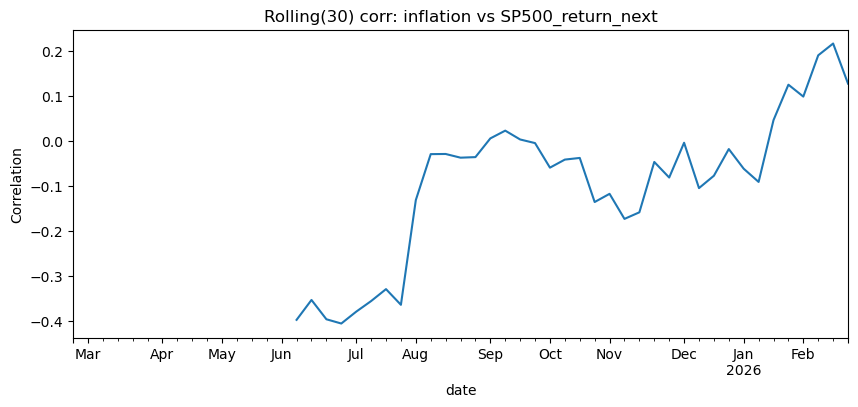

In [16]:
# rolling correlation (window=30) for the whole dataframe
rolling_corr = df.rolling(window=30, min_periods=15).corr()

# display the correlation matrix for the last available date
last_date = rolling_corr.index.max()
display(rolling_corr.loc[last_date])

# example: plot rolling correlation time series for a pair (change columns as desired)
pair_series = df['inflation'].rolling(30, min_periods=15).corr(df['SP500_return_next'])
fig, ax_corr = plt.subplots(figsize=(10, 4))
pair_series.plot(ax=ax_corr, title="Rolling(30) corr: inflation vs SP500_return_next")
ax_corr.set_ylabel("Correlation")
plt.show()

In [21]:
keyword = 'recession'

# Step 2: Create 5 quantile bins based on trend score
df['score_bin'] = pd.qcut(df[keyword], q=5, labels=False)
groups = [group['SP500_return_next'].values for _, group in df.groupby('score_bin')]
*groups

SyntaxError: can't use starred expression here (4056024894.py, line 6)